# Object Detection Pipeline -- YOLO Fine-Tuning Template
## Super AI Engineer Program -- Level 1

**What this notebook does:** End-to-end object detection with YOLO -- from pretrained inference to fine-tuning on custom data. This is the template for any detection hackathon task.

**Pipeline steps:**
1. Setup & install
2. Understand the detection dataset format
3. YOLO inference with pretrained model (before fine-tuning)
4. Fine-tune YOLO on custom data
5. Evaluate (mAP, precision, recall)
6. Run inference on new images
7. Export & hackathon tips
8. DETR comparison (FLEX)

**Runtime:** < 5 minutes total on free Google Colab T4 GPU
**Dataset:** COCO8 (tiny built-in dataset -- 8 images, perfect for demo)

---
## Cell 1: Setup

Run time: ~30 seconds

In [1]:
# STEP 1: Install dependencies
!pip install ultralytics matplotlib Pillow -q

import os
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from ultralytics import YOLO
print(f"Ultralytics version: {__import__('ultralytics').__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00
Using device: cuda
GPU: Tesla T4
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.23


---
## Cell 2: Understand the YOLO Dataset Format

**YOLO dataset structure:**
```
dataset/
  images/
    train/  -> image1.jpg, image2.jpg, ...
    val/    -> image3.jpg, image4.jpg, ...
  labels/
    train/  -> image1.txt, image2.txt, ...
    val/    -> image3.txt, image4.txt, ...
  dataset.yaml  -> paths + class names
```

**Label format** (each line = one object):
```
class_id  x_center  y_center  width  height
0         0.5       0.4       0.3    0.6
```
All coordinates are normalized (0 to 1, relative to image size).

In [2]:
# STEP 2: Explore the COCO8 dataset (built into Ultralytics)
# COCO8 is a tiny 8-image subset of COCO -- perfect for quick demos.
# Ultralytics downloads it automatically when you first reference it.

# Let's look at the dataset.yaml to understand the format
from ultralytics.data.utils import check_det_dataset

# Download and inspect the COCO8 dataset
dataset_info = check_det_dataset('coco8.yaml')
print("Dataset YAML contents:")
print(f"  Train images: {dataset_info.get('train', 'N/A')}")
print(f"  Val images:   {dataset_info.get('val', 'N/A')}")
print(f"  Number of classes: {dataset_info.get('nc', 'N/A')}")

# Show class names
names = dataset_info.get('names', {})
print(f"\nClasses ({len(names)} total):")
for idx, name in names.items():
    print(f"  [{idx}] {name}")


WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 909.3files/s 0.0s
Dataset download success ✅ (0.4s), saved to /content/datasets

Dataset YAML contents:
  Train images: /content/datasets/coco8/images/train
  Val images:   /content/datasets/coco8/images/val
  Number of classes: 80

Classes (80 total):
  [0] person
  [1] bicycle
  [2] car
  [3] motorcycle
  [4] airplane
  [5] bus
  [6] train
  [7] truck
  [8] boat
  [9] traffic light
  [10] fire hydrant
  [11] stop sign
  [12] parking meter
  [13] bench
  [14] bird
  [15] cat
  [16] dog
  [17] horse
  [18] sheep
  [19] cow
  [20] elephant
  [21] bear
  [22] zebra
  [23] giraffe
  [24] backpack
  [25] umbrella
  [26] handbag
  [27] tie
  [28] suitcase
  [29] frisbee
  [30] skis
  [31] snowboard
  [32] sports ball
  [33] kite
  [34] baseball bat
  [35] baseball glove
  [36] skateboard
  [37] surfb

Sample image: /content/datasets/coco8/images/train/000000000009.jpg
Sample label: /content/datasets/coco8/labels/train/000000000009.txt

Label file contents (class_id x_center y_center width height):
  bowl            -> 45 0.479492 0.688771 0.955609 0.5955
  bowl            -> 45 0.736516 0.247188 0.498875 0.476417
  broccoli        -> 50 0.637063 0.732938 0.494125 0.510583
  bowl            -> 45 0.339438 0.418896 0.678875 0.7815
  orange          -> 49 0.646836 0.132552 0.118047 0.0969375


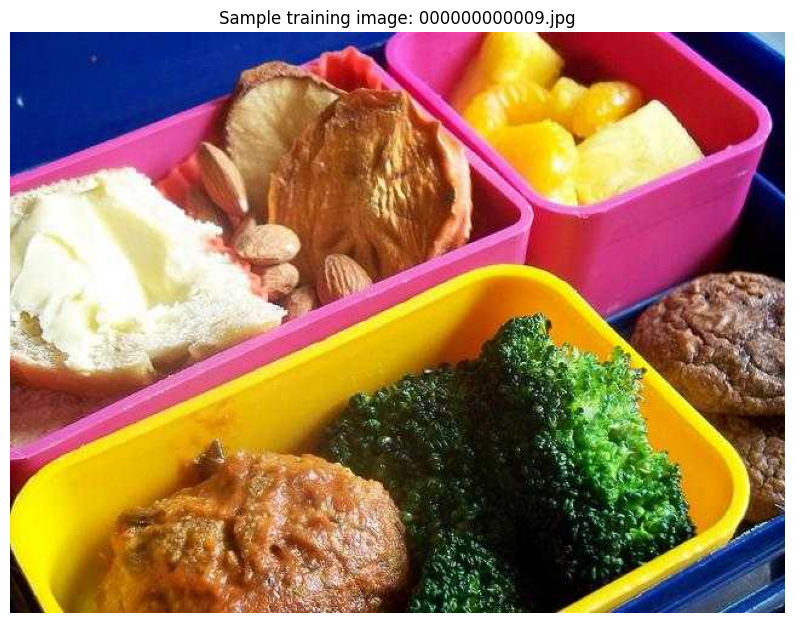

Image size: (640, 480)


In [3]:
# Show a sample image with its label file
# This helps you understand what YOLO label files look like

import glob

# Find training images
train_img_dir = str(dataset_info.get('train', ''))
if os.path.isdir(train_img_dir):
    img_files = sorted(glob.glob(os.path.join(train_img_dir, '*.jpg')))
else:
    # Fallback: search in datasets directory
    img_files = sorted(glob.glob(os.path.join('datasets', 'coco8', 'images', 'train', '*.jpg')))

if img_files:
    sample_img_path = img_files[0]
    # Corresponding label file
    sample_label_path = sample_img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    print(f"Sample image: {sample_img_path}")
    print(f"Sample label: {sample_label_path}")

    if os.path.exists(sample_label_path):
        print(f"\nLabel file contents (class_id x_center y_center width height):")
        with open(sample_label_path, 'r') as f:
            for line in f.readlines()[:5]:  # Show first 5 objects
                parts = line.strip().split()
                cls_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]
                cls_name = names.get(cls_id, f"class_{cls_id}")
                print(f"  {cls_name:15s} -> {line.strip()}")

    # Show the image
    img = Image.open(sample_img_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Sample training image: {os.path.basename(sample_img_path)}", fontsize=12)
    plt.axis('off')
    plt.show()
    print(f"Image size: {img.size}")
else:
    print("Could not find training images -- dataset may still be downloading.")

---
## Cell 3: YOLO Inference (Before Fine-Tuning)

In [4]:
# STEP 3: Run pretrained YOLO on sample images (BEFORE fine-tuning)
# This shows what the model can do out-of-the-box

# Load pretrained YOLOv8-nano (smallest, fastest)
pretrained_model = YOLO('yolov8n.pt')

# Run inference on sample images
if img_files:
    results = pretrained_model(img_files[:4], verbose=False)  # First 4 images

    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for idx, (result, ax) in enumerate(zip(results, axes.flat)):
        # Get the plotted image with bounding boxes
        plotted = result.plot()  # Returns BGR numpy array
        ax.imshow(plotted[:, :, ::-1])  # Convert BGR to RGB
        n_detections = len(result.boxes)
        ax.set_title(f"Image {idx+1}: {n_detections} detections", fontsize=11)
        ax.axis('off')

    plt.suptitle("Pretrained YOLO -- Before Fine-Tuning (80 COCO classes)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print detection details for the first image
    print(f"\nDetailed results for Image 1:")
    print(f"{'Class':<15} {'Confidence':<12} {'Box (xyxy)'}")
    print("-" * 55)
    for box in results[0].boxes:
        cls_name = pretrained_model.names[int(box.cls)]
        conf = float(box.conf)
        xyxy = box.xyxy[0].cpu().numpy()
        print(f"{cls_name:<15} {conf:<12.1%} [{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]")

Output hidden; open in https://colab.research.google.com to view.

---
## Cell 4: Fine-Tune YOLO on Custom Data

Run time: ~3-5 minutes on T4 GPU (15 epochs on COCO8)

While training runs, pay attention to:
- **box_loss**: How well the model predicts bounding box locations (lower = better)
- **cls_loss**: How well the model classifies objects (lower = better)
- **mAP50**: Mean Average Precision at IoU 0.5 (higher = better, max = 1.0)

In [5]:
# STEP 4: Fine-tune YOLO on our dataset
# This is the core of the notebook -- 3 lines of real code!

import time

# Line 1: Load pretrained YOLO (start from ImageNet + COCO weights)
model = YOLO('yolov8n.pt')  # nano = smallest & fastest. Use 's', 'm', 'l' for more accuracy.

# Line 2: Fine-tune on our custom dataset
start_time = time.time()

results = model.train(
    data='coco8.yaml',       # Path to dataset config (CHANGE THIS for your dataset)
    epochs=15,               # 15 epochs is enough for a demo; use 50-100 for real training
    imgsz=640,               # Standard YOLO input size
    batch=16,                # Adjust based on GPU memory (reduce to 8 if OOM)
    device=0,                # Use GPU (set to 'cpu' if no GPU)
    verbose=True,            # Show training progress
    project='runs/detect',   # Output directory
    name='flower_detector',  # Experiment name
    exist_ok=True,           # Overwrite if exists
)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)!")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=flower_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

---
## Cell 5: Evaluate the Fine-Tuned Model

In [6]:
# STEP 5: Evaluate on validation set
# Load the best weights from training
best_model_path = 'runs/detect/flower_detector/weights/best.pt'
if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
else:
    # Fallback: use last model
    best_model = model
    print("Using last epoch weights (best.pt not found)")

# Run validation
metrics = best_model.val(data='coco8.yaml', verbose=False)

print("EVALUATION METRICS")
print("=" * 50)
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")

# Show training curves if available
results_dir = 'runs/detect/flower_detector'
results_img = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img):
    img = Image.open(results_img)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title("Training Curves (Loss, mAP, Precision, Recall)", fontsize=13)
    plt.axis('off')
    plt.show()
else:
    print("\nTraining curves image not found.")

Using last epoch weights (best.pt not found)
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1945.3±862.7 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.0it/s 0.2s
                   all          4         17      0.803      0.833      0.889      0.642
Speed: 2.4ms preprocess, 27.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
EVALUATION METRICS
mAP50:      0.8890
mAP50-95:   0.6421
Precision:  0.8027
Recall:     0.8333

Training curves image not found.


In [7]:
# Show detection results on validation images
# Compare BEFORE fine-tuning vs AFTER fine-tuning

if img_files:
    test_images = img_files[:4]

    # After fine-tuning
    after_results = best_model(test_images, verbose=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for idx, (result, ax) in enumerate(zip(after_results, axes.flat)):
        plotted = result.plot()
        ax.imshow(plotted[:, :, ::-1])
        n_det = len(result.boxes)
        ax.set_title(f"After Fine-Tuning: {n_det} detections", fontsize=11)
        ax.axis('off')

    plt.suptitle("Fine-Tuned YOLO -- Detection Results",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## Cell 6: Run Inference on New Images

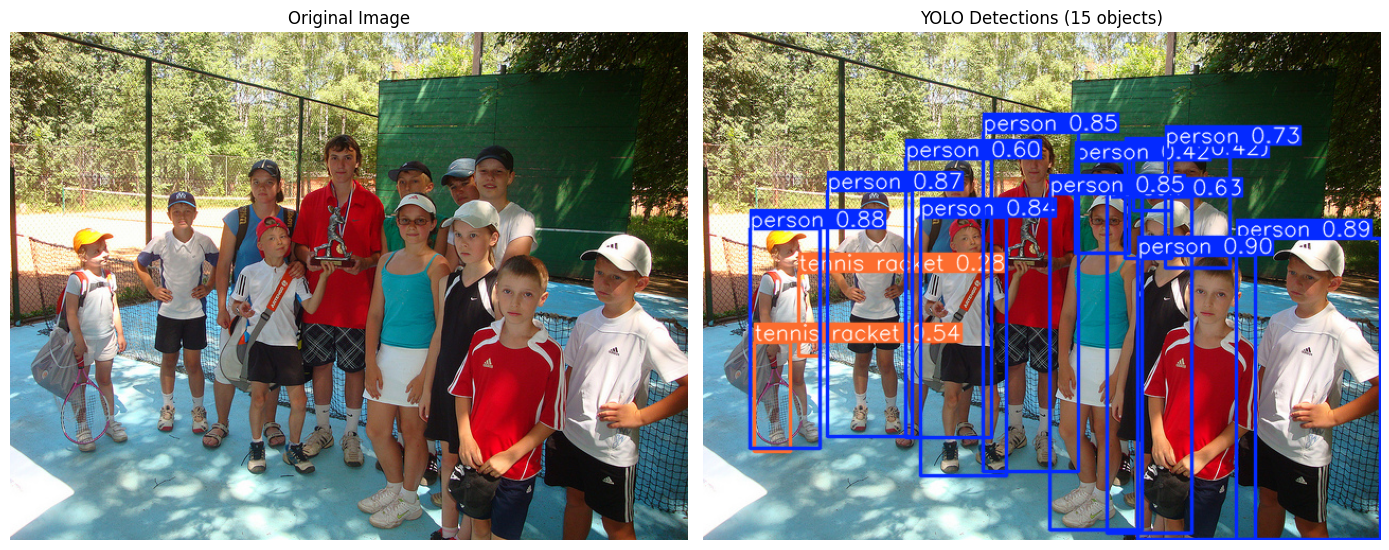


Detections:
Class           Confidence   Box (x1,y1,x2,y2)
------------------------------------------------------------
person          89.5%        [411, 211, 522, 480]
person          89.3%        [503, 196, 640, 480]
person          88.1%        [44, 186, 111, 394]
person          87.5%        [118, 151, 198, 382]
person          85.4%        [327, 153, 415, 471]
person          85.0%        [264, 96, 354, 415]
person          83.8%        [205, 176, 287, 420]
person          73.2%        [436, 107, 497, 223]
person          62.9%        [381, 156, 461, 474]
person          60.3%        [192, 120, 273, 384]
tennis racket   54.0%        [48, 294, 83, 396]
person          42.4%        [351, 122, 403, 209]
person          41.9%        [398, 118, 442, 214]
person          29.9%        [407, 119, 442, 170]
tennis racket   28.1%        [90, 228, 111, 307]

Result saved to detection_result.jpg


In [16]:
# STEP 6: Run inference on new images with your fine-tuned model

# Download a sample image from the internet
import requests

sample_url = "http://images.cocodataset.org/val2017/000000001000.jpg"
img_data = requests.get(sample_url).content
with open("test_image.jpg", "wb") as f:
    f.write(img_data)

# Run inference -- ONE LINE
results = best_model("test_image.jpg", verbose=False)

# Display result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original image
original = Image.open("test_image.jpg")
ax1.imshow(original)
ax1.set_title("Original Image", fontsize=12)
ax1.axis('off')

# Detection result
plotted = results[0].plot()
ax2.imshow(plotted[:, :, ::-1])
ax2.set_title(f"YOLO Detections ({len(results[0].boxes)} objects)", fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

# Print all detections
print(f"\nDetections:")
print(f"{'Class':<15} {'Confidence':<12} {'Box (x1,y1,x2,y2)'}")
print("-" * 60)
for box in results[0].boxes:
    cls_name = best_model.names[int(box.cls)]
    conf = float(box.conf)
    xyxy = box.xyxy[0].cpu().numpy()
    print(f"{cls_name:<15} {conf:<12.1%} [{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]")

# Save the result
results[0].save('detection_result.jpg')
print(f"\nResult saved to detection_result.jpg")

---
## Cell 7: Export & Hackathon Tips
> SPEAKER NOTE: "Once your model is trained, you can export it to different formats for deployment. ONNX is the most common for production. But for hackathons, the .pt weights file is all you need."

In [9]:
# STEP 7: Export model (optional -- for deployment)

# Export to ONNX format (most common for deployment)
# Uncomment the line below to export:
# best_model.export(format='onnx')

# Show model info
print("MODEL SUMMARY")
print("=" * 50)
print(f"Model: YOLOv8-nano (fine-tuned)")
print(f"Weights: {best_model_path}")
if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / 1024 / 1024
    print(f"File size: {size_mb:.1f} MB")
print(f"Classes: {len(best_model.names)}")
print()

# Hackathon tips
print("HACKATHON TIPS FOR DETECTION")
print("=" * 50)
tips = [
    "1. Start with yolov8n (nano). Upgrade to 's' or 'm' only if accuracy needs it.",
    "2. More training data > bigger model. Always.",
    "3. Use Roboflow (roboflow.com) to quickly annotate and export in YOLO format.",
    "4. Train for at least 50 epochs on real datasets (we used 15 for demo speed).",
    "5. If GPU memory is an issue, reduce batch size (16 -> 8 -> 4) or image size (640 -> 320).",
    "6. Data augmentation is built into YOLO training -- it does mosaic, mixup, etc. automatically.",
    "7. Check the confusion matrix in runs/detect/your_exp/ to see which classes are confused.",
    "8. For Thai text detection, YOLO works great as the first stage of an OCR pipeline.",
]
for tip in tips:
    print(f"  {tip}")

MODEL SUMMARY
Model: YOLOv8-nano (fine-tuned)
Weights: runs/detect/flower_detector/weights/best.pt
Classes: 80

HACKATHON TIPS FOR DETECTION
  1. Start with yolov8n (nano). Upgrade to 's' or 'm' only if accuracy needs it.
  2. More training data > bigger model. Always.
  3. Use Roboflow (roboflow.com) to quickly annotate and export in YOLO format.
  4. Train for at least 50 epochs on real datasets (we used 15 for demo speed).
  5. If GPU memory is an issue, reduce batch size (16 -> 8 -> 4) or image size (640 -> 320).
  6. Data augmentation is built into YOLO training -- it does mosaic, mixup, etc. automatically.
  7. Check the confusion matrix in runs/detect/your_exp/ to see which classes are confused.
  8. For Thai text detection, YOLO works great as the first stage of an OCR pipeline.


---
## Cell 8: DETR Quick Comparison (FLEX)
> SPEAKER NOTE: "YOLO is fast and easy to fine-tune -- perfect for hackathons. DETR is sometimes more accurate on crowded scenes with overlapping objects. Let's see both on the same image. For hackathons: always start with YOLO."

This cell is **FLEX content** -- can be skipped if short on time.

Loading DETR model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


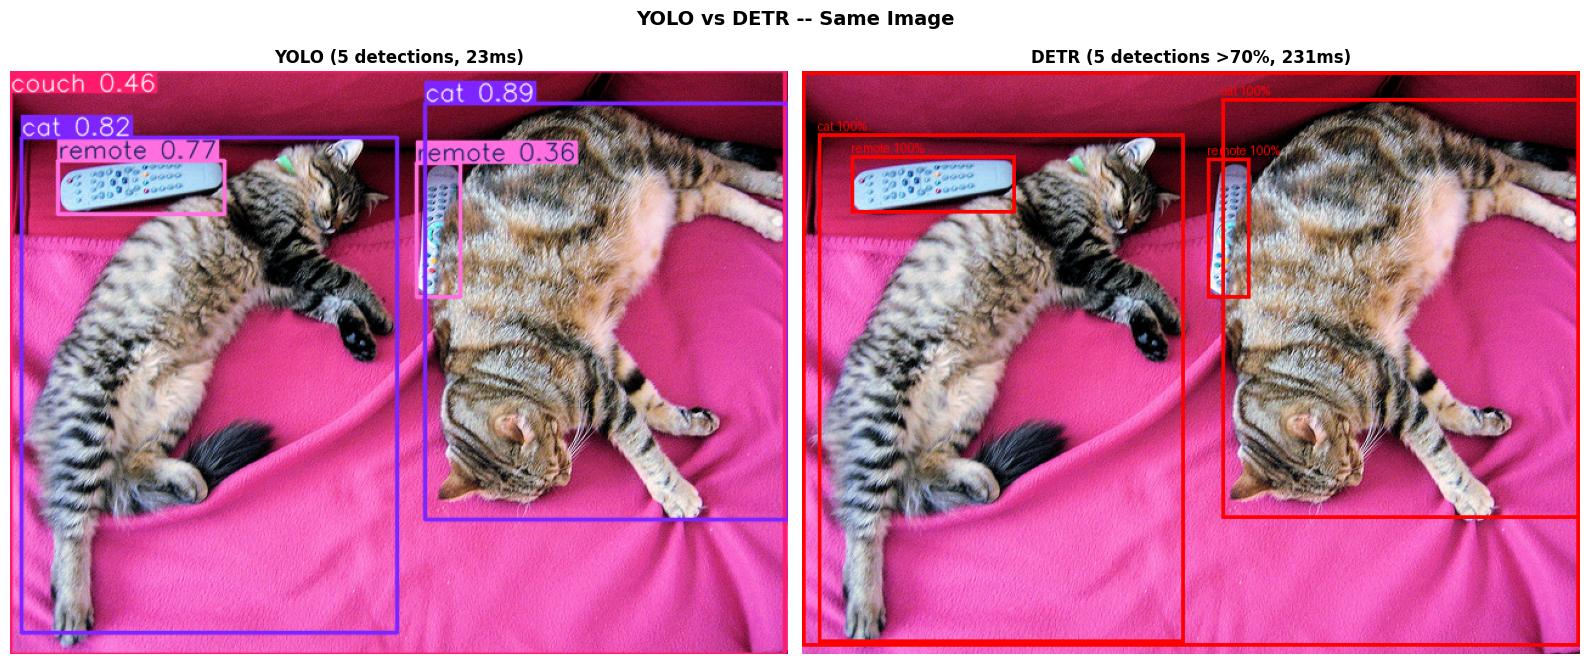


YOLO vs DETR COMPARISON
Metric               YOLO            DETR           
--------------------------------------------------
Speed                Fast            Moderate       
Inference time       23ms            231ms          
Fine-tuning          3 lines         Complex        
Best for             Hackathons      Complex scenes 
Framework            Ultralytics     HuggingFace    

VERDICT: For hackathons, start with YOLO. Always.


In [10]:
# STEP 8 (FLEX): DETR comparison -- Transformer-based detection
# Install transformers if not already installed
!pip install transformers -q

from transformers import pipeline as hf_pipeline
from PIL import Image, ImageDraw

# Load DETR model
print("Loading DETR model...")
detr_detector = hf_pipeline("object-detection", model="facebook/detr-resnet-50", device=0 if device == 'cuda' else -1)

# Run on the same test image
test_img = Image.open("test_image.jpg")

# DETR inference
import time
detr_start = time.time()
detr_results = detr_detector(test_img)
detr_time = time.time() - detr_start

# YOLO inference on same image
yolo_start = time.time()
yolo_results = best_model("test_image.jpg", verbose=False)
yolo_time = time.time() - yolo_start

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# YOLO result
yolo_plotted = yolo_results[0].plot()
ax1.imshow(yolo_plotted[:, :, ::-1])
ax1.set_title(f"YOLO ({len(yolo_results[0].boxes)} detections, {yolo_time*1000:.0f}ms)", fontsize=12, fontweight='bold')
ax1.axis('off')

# DETR result -- draw boxes manually
detr_img = test_img.copy()
draw = ImageDraw.Draw(detr_img)
for det in detr_results:
    if det['score'] > 0.7:  # Only show high-confidence detections
        box = det['box']
        draw.rectangle([box['xmin'], box['ymin'], box['xmax'], box['ymax']], outline='red', width=3)
        draw.text((box['xmin'], box['ymin'] - 12), f"{det['label']} {det['score']:.0%}", fill='red')

ax2.imshow(detr_img)
high_conf = sum(1 for d in detr_results if d['score'] > 0.7)
ax2.set_title(f"DETR ({high_conf} detections >70%, {detr_time*1000:.0f}ms)", fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle("YOLO vs DETR -- Same Image", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparison table
print("\nYOLO vs DETR COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'YOLO':<15} {'DETR':<15}")
print("-" * 50)
print(f"{'Speed':<20} {'Fast':<15} {'Moderate':<15}")
print(f"{'Inference time':<20} {f'{yolo_time*1000:.0f}ms':<15} {f'{detr_time*1000:.0f}ms':<15}")
print(f"{'Fine-tuning':<20} {'3 lines':<15} {'Complex':<15}")
print(f"{'Best for':<20} {'Hackathons':<15} {'Complex scenes':<15}")
print(f"{'Framework':<20} {'Ultralytics':<15} {'HuggingFace':<15}")
print()
print("VERDICT: For hackathons, start with YOLO. Always.")

---
## What to Change for YOUR Dataset

### 1. Prepare your dataset
Use [Roboflow](https://roboflow.com) to annotate your images and export in YOLO format. It handles the folder structure and label files automatically. Free tier supports up to 10,000 images.

### 2. Create a dataset.yaml file
```yaml
# my_dataset.yaml
path: /path/to/your/dataset
train: images/train
val: images/val
nc: 3  # CHANGE THIS to your number of classes
names: ['class_a', 'class_b', 'class_c']  # CHANGE THIS to your class names
```

### 3. Train with your data
```python
model = YOLO('yolov8n.pt')
model.train(data='my_dataset.yaml', epochs=50, imgsz=640)
```

### 4. Model size guide
| Model | Size | Speed | Accuracy | Use When |
|-------|------|-------|----------|----------|
| yolov8n | 6 MB | Fastest | Good | Hackathon prototyping, real-time |
| yolov8s | 22 MB | Fast | Better | Good balance of speed and accuracy |
| yolov8m | 52 MB | Medium | Great | More accuracy needed, have GPU time |
| yolov8l | 87 MB | Slow | Excellent | Best accuracy, not time-constrained |

### 5. If mAP is low:
- Add more training data (most impactful)
- Train for more epochs (50-100)
- Try a bigger model (s -> m -> l)
- Add more diverse training images
- Check that your annotations are correct